# Chapter 5 — Decision Trees

> *Hands-On Machine Learning with Scikit-Learn, Keras & PyTorch* — Aurélien Géron (2025)

---

In [1]:
import sys
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-Learn
from sklearn.datasets import load_iris, make_moons, make_regression
from sklearn.tree import (DecisionTreeClassifier, DecisionTreeRegressor,
                           export_graphviz, plot_tree)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler

# Reproducibility
np.random.seed(42)

# Shared data path — works from any chapter subfolder
DATA_PATH = Path('../data')

## Training and Visualizing a Decision Tree

In [2]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[['sepal length (cm)', 'sepal width (cm)']].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [3]:
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file='iris_tree.dot',
    feature_names=['sepal length (cm)', 'sepal width (cm)'],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)

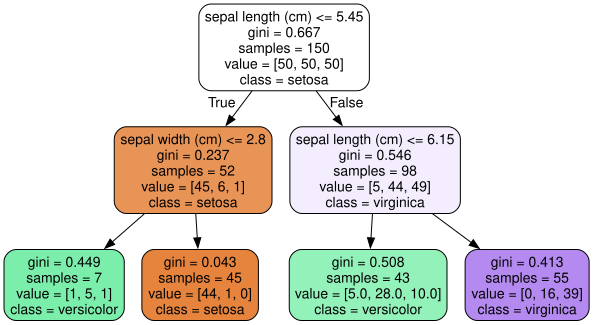

In [4]:
from graphviz import Source

Source.from_file("iris_tree.dot")

## Making Predictions

la gini impurity se calcula como:
$$G = 1 - \sum_{k=1}^{n} p_k^2$$

donde $p_k$ es la proporción de muestras que pertenecen a la clase $k$ en el nodo.


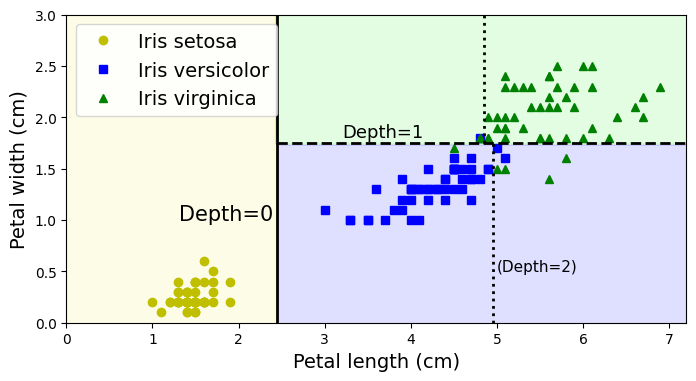

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# extra code – just formatting details
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
plt.figure(figsize=(8, 4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

# extra code – this section beautifies Figure 5–2
tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(X_iris, y_iris)
th0, th1, th2a, th2b = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.plot([th0, th0], [0, 3], "k-", linewidth=2)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2)
plt.plot([th2a, th2a], [0, th1], "k:", linewidth=2)
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth=2)
plt.text(th0 - 0.05, 1.0, "Depth=0", horizontalalignment="right", fontsize=15)
plt.text(3.2, th1 + 0.02, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.text(th2a + 0.05, 0.5, "(Depth=2)", fontsize=11)
plt.axis([0, 7.2, 0, 3])
plt.legend()

plt.show()

## Estimating Class Probabilities

In [ ]:
tree_clf.predict_proba([[5, 1.5]]).round(3)

array([[0.143, 0.714, 0.143]])

In [7]:
tree_clf.predict([[5, 1.5]])

array([1])

## The CART Training Algorithm

🌳 Entendiendo la Función de Costo CARTImagina que eres un organizador de eventos y tienes un grupo de 100 personas mezcladas (algunas aman el rock y otras el pop). Tu misión es dividirlas en dos salas diferentes, pero quieres que cada sala sea lo más "pura" posible (que no haya mezclas).La fórmula CART es la herramienta que usas para decidir dónde poner la pared divisoria.La Fórmula MatemáticaPara un par determinado de (característica $k$, umbral $t_k$), el costo se calcula así:$$J(k, t_k) = \frac{m_{\text{izq}}}{m} G_{\text{izq}} + \frac{m_{\text{der}}}{m} G_{\text{der}}$$¿Qué significa cada pieza? 🤔No la veas como una ecuación rígida, mírala como un promedio ponderado de suciedad.1. Las Proporciones ($\frac{m_{\text{izq}}}{m}$ y $\frac{m_{\text{der}}}{m}$)$m$ es el total de personas.$m_{\text{izq}}$ y $m_{\text{der}}$ son cuántas personas terminaron en cada sala.Intuición: Estas fracciones le dicen al algoritmo: 
"Dale más importancia a la sala que tenga más gente". No sirve de nada limpiar perfectamente una sala donde solo hay 1 persona si la sala con 99 personas sigue siendo un caos total.2. La Impureza de Gini ($G_{\text{izq}}$ y $G_{\text{der}}$)Es el nivel de "mezcla" o "suciedad" en cada sala.Si una sala tiene 100% fans de rock, su $G$ es 0 (Pureza total).Si está mitad y mitad, su $G$ es alto (Caos total).

## Computational Complexity

El rendimiento de un Árbol de Decisión se divide en dos fases: **Predicción** (muy rápida) y **Entrenamiento** (más costosa).

---

### 1. Fase de Predicción: $O(\log_2(m))$
Para clasificar una nueva instancia, el modelo recorre el árbol desde la raíz hasta una hoja.
* **Eficiencia:** El tiempo es proporcional al logaritmo del número de instancias de entrenamiento ($m$). 
* **Independencia:** Es **independiente del número de características ($n$)**, ya que en cada nodo solo se evalúa una variable.
* **Ejemplo:** Si entrenaste con 1,000,000 de muestras, el árbol tendrá una profundidad de ~20. Predecir solo requiere 20 comparaciones de "sí/no".

### 2. Fase de Entrenamiento: $O(n \times m \log_2(m))$
El algoritmo CART es exhaustivo porque busca el mejor corte en cada nivel.
* **Costo:** Compara **todas** las características ($n$) en **todas** las muestras ($m$) en cada nodo.
* **Escalabilidad:** Si el dataset es muy grande o tiene miles de columnas, el tiempo de entrenamiento crecerá significativamente.

---

### 🛠️ Control de Velocidad y Overfitting

Puedes optimizar el tiempo de entrenamiento y mejorar la generalización ajustando estos hiperparámetros:

| Hiperparámetro | Impacto en Complejidad | Función |
| :--- | :--- | :--- |
| `max_depth` | ⬇️ Reduce profundidad | Evita que el árbol crezca indefinidamente (Overfitting). |
| `max_features` | ⬇️ Reduce $n$ evaluado | Elige un subconjunto aleatorio de variables en cada nodo. |
| `min_samples_leaf` | ⬇️ Limita divisiones | Asegura que cada hoja tenga un mínimo de muestras. |

> **Nota:** Limitar la complejidad no solo acelera el modelo, sino que lo obliga a aprender patrones generales en lugar de memorizar el ruido de los datos.


## Gini vs. Entropía

La ecuación de la impureza de Gini es:
$$G = 1 - \sum_{k=1}^{n} p_k^2$$
donde $p_k$ es la proporción de muestras que pertenecen a la clase $k$ en el nodo.

La fórmula de la entropía es:
$$H = -\sum_{k=1}^{n} p_k \log_2(p_k)$$
donde $p_k$ es la proporción de muestras que pertenecen a la clase $k$ en el nodo.